# 3D Spectral-Spatial Autoencoder for Hyperspectral Anomaly Detection

This notebook develops a three-dimensional convolutional autoencoder for hyperspectral anomaly detection.

Unlike the previous models, this model uses both spectral information and spatial context. Each pixel is represented by a local hyperspectral patch centered around that pixel.

Principal component analysis is first used to reduce the spectral dimension. The 3D autoencoder then learns to reconstruct local spectral-spatial structures. Pixels with high center-pixel reconstruction error are treated as potential anomalies.

In [2]:
import os
import random
import time
import copy
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.io import loadmat

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    classification_report,
    confusion_matrix
)

import torch

from torch import nn

from torch.utils.data import (
    Dataset,
    DataLoader,
    random_split
)

import joblib

warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


In [4]:
RANDOM_STATE = 42

random.seed(
    RANDOM_STATE
)

np.random.seed(
    RANDOM_STATE
)

torch.manual_seed(
    RANDOM_STATE
)

if torch.cuda.is_available():

    torch.cuda.manual_seed_all(
        RANDOM_STATE
    )

    torch.backends.cudnn.deterministic = True

    torch.backends.cudnn.benchmark = False

print(
    "Random seed set to:",
    RANDOM_STATE
)

Random seed set to: 42


In [6]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(
    "Device being used:",
    device
)

Device being used: cpu


In [10]:
DATA_PATH = "/Users/monicachaganti/Desktop/hyperspectral-anomaly-detection/data/aviris_1.mat"

RESULTS_DIR = "../results"

MODELS_DIR = "../models"

os.makedirs(
    RESULTS_DIR,
    exist_ok=True
)

os.makedirs(
    MODELS_DIR,
    exist_ok=True
)

print(
    "Dataset path:",
    DATA_PATH
)

print(
    "Results directory:",
    RESULTS_DIR
)

print(
    "Models directory:",
    MODELS_DIR
)

Dataset path: /Users/monicachaganti/Desktop/hyperspectral-anomaly-detection/data/aviris_1.mat
Results directory: ../results
Models directory: ../models


In [12]:
if not os.path.exists(
    DATA_PATH
):

    raise FileNotFoundError(
        f"Dataset not found at {DATA_PATH}. "
        "Place aviris_1.mat inside the data folder."
    )

print(
    "Dataset found successfully."
)

Dataset found successfully.


In [14]:
mat_file = loadmat(
    DATA_PATH
)

print(
    "Variables inside the MAT file:"
)

for key, value in mat_file.items():

    if not key.startswith("__"):

        print(
            key,
            type(value),
            getattr(
                value,
                "shape",
                None
            )
        )

Variables inside the MAT file:
data <class 'numpy.ndarray'> (100, 100, 189)
map <class 'numpy.ndarray'> (100, 100)


In [16]:
cube = mat_file[
    "data"
].astype(
    np.float32
)

ground_truth = np.squeeze(
    mat_file["map"]
)

ground_truth = (
    ground_truth > 0
).astype(
    np.uint8
)

print(
    "Hyperspectral cube shape:",
    cube.shape
)

print(
    "Ground-truth shape:",
    ground_truth.shape
)

print(
    "Ground-truth values:",
    np.unique(
        ground_truth
    )
)

Hyperspectral cube shape: (100, 100, 189)
Ground-truth shape: (100, 100)
Ground-truth values: [0 1]


In [18]:
cube = np.nan_to_num(
    cube,
    nan=0.0,
    posinf=0.0,
    neginf=0.0
)

print(
    "NaN values:",
    np.isnan(cube).sum()
)

print(
    "Infinite values:",
    np.isinf(cube).sum()
)

NaN values: 0
Infinite values: 0


In [20]:
height, width, bands = cube.shape

total_pixels = height * width

print(
    "Image height:",
    height
)

print(
    "Image width:",
    width
)

print(
    "Number of spectral bands:",
    bands
)

print(
    "Total number of pixels:",
    total_pixels
)

Image height: 100
Image width: 100
Number of spectral bands: 189
Total number of pixels: 10000


In [22]:
number_of_anomalies = int(
    ground_truth.sum()
)

number_of_background_pixels = (
    total_pixels
    - number_of_anomalies
)

anomaly_percentage = (
    number_of_anomalies
    / total_pixels
) * 100

print(
    "Background pixels:",
    number_of_background_pixels
)

print(
    "Anomaly pixels:",
    number_of_anomalies
)

print(
    f"Anomaly percentage: "
    f"{anomaly_percentage:.4f}%"
)

Background pixels: 9936
Anomaly pixels: 64
Anomaly percentage: 0.6400%


In [24]:
X = cube.reshape(
    -1,
    bands
)

y = ground_truth.reshape(
    -1
)

print(
    "Feature matrix shape:",
    X.shape
)

print(
    "Label vector shape:",
    y.shape
)

Feature matrix shape: (10000, 189)
Label vector shape: (10000,)


In [26]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    X
).astype(
    np.float32
)

print(
    "Scaled feature matrix shape:",
    X_scaled.shape
)

print(
    "Scaled mean:",
    X_scaled.mean()
)

print(
    "Scaled standard deviation:",
    X_scaled.std()
)

Scaled feature matrix shape: (10000, 189)
Scaled mean: 6.9754464e-09
Scaled standard deviation: 0.9999999


In [28]:
NUMBER_OF_PCA_COMPONENTS = 16

pca = PCA(
    n_components=NUMBER_OF_PCA_COMPONENTS,
    random_state=RANDOM_STATE
)

X_pca = pca.fit_transform(
    X_scaled
).astype(
    np.float32
)

print(
    "Original feature shape:",
    X_scaled.shape
)

print(
    "PCA feature shape:",
    X_pca.shape
)

print(
    f"Explained variance: "
    f"{pca.explained_variance_ratio_.sum() * 100:.2f}%"
)

Original feature shape: (10000, 189)
PCA feature shape: (10000, 16)
Explained variance: 99.95%


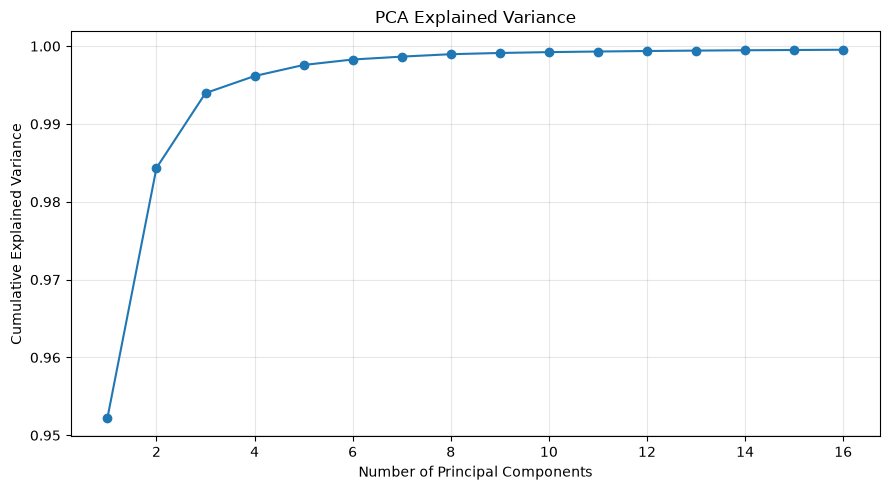

In [30]:
cumulative_variance = np.cumsum(
    pca.explained_variance_ratio_
)

plt.figure(
    figsize=(9, 5)
)

plt.plot(
    range(
        1,
        NUMBER_OF_PCA_COMPONENTS + 1
    ),
    cumulative_variance,
    marker="o"
)

plt.xlabel(
    "Number of Principal Components"
)

plt.ylabel(
    "Cumulative Explained Variance"
)

plt.title(
    "PCA Explained Variance"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()

In [32]:
pca_cube = X_pca.reshape(
    height,
    width,
    NUMBER_OF_PCA_COMPONENTS
)

print(
    "PCA cube shape:",
    pca_cube.shape
)

PCA cube shape: (100, 100, 16)


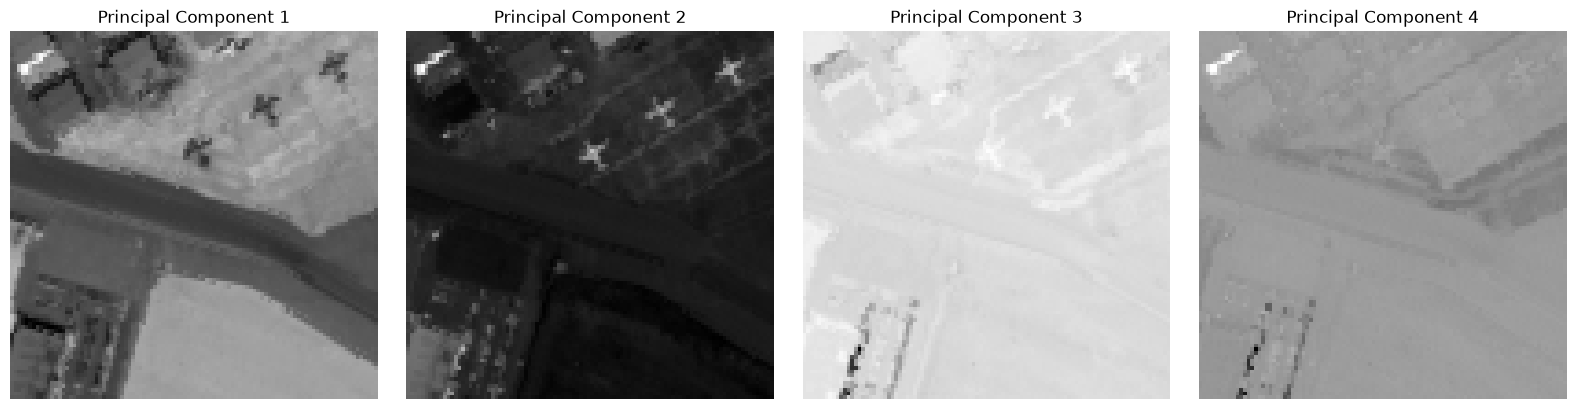

In [34]:
figure, axes = plt.subplots(
    1,
    4,
    figsize=(16, 4)
)

for component_index in range(4):

    axes[
        component_index
    ].imshow(
        pca_cube[
            :,
            :,
            component_index
        ],
        cmap="gray"
    )

    axes[
        component_index
    ].set_title(
        f"Principal Component "
        f"{component_index + 1}"
    )

    axes[
        component_index
    ].axis(
        "off"
    )

plt.tight_layout()

plt.show()

In [36]:
PATCH_SIZE = 9

PATCH_HALF_SIZE = (
    PATCH_SIZE // 2
)

print(
    "Patch size:",
    PATCH_SIZE
)

print(
    "Patch half size:",
    PATCH_HALF_SIZE
)

Patch size: 9
Patch half size: 4


In [38]:
padded_pca_cube = np.pad(
    pca_cube,
    (
        (
            PATCH_HALF_SIZE,
            PATCH_HALF_SIZE
        ),
        (
            PATCH_HALF_SIZE,
            PATCH_HALF_SIZE
        ),
        (
            0,
            0
        )
    ),
    mode="reflect"
)

print(
    "Original PCA cube shape:",
    pca_cube.shape
)

print(
    "Padded PCA cube shape:",
    padded_pca_cube.shape
)

Original PCA cube shape: (100, 100, 16)
Padded PCA cube shape: (108, 108, 16)


In [40]:
class HyperspectralPatchDataset(
    Dataset
):

    def __init__(
        self,
        padded_cube,
        image_height,
        image_width,
        patch_size
    ):

        self.padded_cube = padded_cube

        self.image_height = image_height

        self.image_width = image_width

        self.patch_size = patch_size

    def __len__(
        self
    ):

        return (
            self.image_height
            * self.image_width
        )

    def __getitem__(
        self,
        index
    ):

        row = (
            index
            // self.image_width
        )

        column = (
            index
            % self.image_width
        )

        patch = self.padded_cube[
            row:
            row + self.patch_size,
            column:
            column + self.patch_size,
            :
        ]

        patch = np.transpose(
            patch,
            (
                2,
                0,
                1
            )
        )

        patch = np.expand_dims(
            patch,
            axis=0
        )

        patch_tensor = torch.tensor(
            patch,
            dtype=torch.float32
        )

        return patch_tensor

In [42]:
patch_dataset = HyperspectralPatchDataset(
    padded_cube=padded_pca_cube,
    image_height=height,
    image_width=width,
    patch_size=PATCH_SIZE
)

print(
    "Number of patches:",
    len(patch_dataset)
)

print(
    "Single patch shape:",
    patch_dataset[0].shape
)

Number of patches: 10000
Single patch shape: torch.Size([1, 16, 9, 9])


In [44]:
training_size = int(
    0.85
    * len(patch_dataset)
)

validation_size = (
    len(patch_dataset)
    - training_size
)

training_dataset, validation_dataset = random_split(
    patch_dataset,
    [
        training_size,
        validation_size
    ],
    generator=torch.Generator().manual_seed(
        RANDOM_STATE
    )
)

print(
    "Training patches:",
    len(training_dataset)
)

print(
    "Validation patches:",
    len(validation_dataset)
)

Training patches: 8500
Validation patches: 1500


In [46]:
BATCH_SIZE = 32

training_loader = DataLoader(
    training_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print(
    "Training batches:",
    len(training_loader)
)

print(
    "Validation batches:",
    len(validation_loader)
)

Training batches: 266
Validation batches: 47


In [48]:
class Patch3DAutoencoder(
    nn.Module
):

    def __init__(
        self
    ):

        super().__init__()

        self.encoder = nn.Sequential(

            nn.Conv3d(
                in_channels=1,
                out_channels=8,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.Conv3d(
                in_channels=8,
                out_channels=16,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool3d(
                kernel_size=(
                    2,
                    2,
                    2
                )
            ),

            nn.Conv3d(
                in_channels=16,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU()
        )

        self.decoder = nn.Sequential(

            nn.Upsample(
                scale_factor=(
                    2,
                    2,
                    2
                ),
                mode="trilinear",
                align_corners=False
            ),

            nn.Conv3d(
                in_channels=32,
                out_channels=16,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.Conv3d(
                in_channels=16,
                out_channels=8,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.Conv3d(
                in_channels=8,
                out_channels=1,
                kernel_size=3,
                padding=1
            )
        )

    def forward(
        self,
        x
    ):

        latent_features = self.encoder(
            x
        )

        reconstructed_patch = self.decoder(
            latent_features
        )

        reconstructed_patch = reconstructed_patch[
            :,
            :,
            :x.shape[2],
            :x.shape[3],
            :x.shape[4]
        ]

        return reconstructed_patch

In [50]:
model = Patch3DAutoencoder()

model = model.to(
    device
)

print(
    model
)

Patch3DAutoencoder(
  (encoder): Sequential(
    (0): Conv3d(1, 8, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (1): ReLU()
    (2): Conv3d(8, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (3): ReLU()
    (4): MaxPool3d(kernel_size=(2, 2, 2), stride=(2, 2, 2), padding=0, dilation=1, ceil_mode=False)
    (5): Conv3d(16, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (6): ReLU()
  )
  (decoder): Sequential(
    (0): Upsample(scale_factor=(2.0, 2.0, 2.0), mode='trilinear')
    (1): Conv3d(32, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (2): ReLU()
    (3): Conv3d(16, 8, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (4): ReLU()
    (5): Conv3d(8, 1, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
  )
)


In [52]:
example_batch = next(
    iter(
        training_loader
    )
)

example_batch = example_batch.to(
    device
)

with torch.no_grad():

    example_output = model(
        example_batch
    )

print(
    "Input shape:",
    example_batch.shape
)

print(
    "Output shape:",
    example_output.shape
)

Input shape: torch.Size([32, 1, 16, 9, 9])
Output shape: torch.Size([32, 1, 16, 8, 8])


In [54]:
number_of_parameters = sum(

    parameter.numel()

    for parameter in model.parameters()

    if parameter.requires_grad
)

print(
    "Number of trainable parameters:",
    number_of_parameters
)

Number of trainable parameters: 35073


In [56]:
loss_function = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=0.00001
)

print(
    "Loss function:",
    loss_function
)

print(
    "Optimizer:",
    optimizer
)

Loss function: MSELoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 1e-05
)


In [58]:
def train_patch_autoencoder(
    model,
    training_loader,
    validation_loader,
    loss_function,
    optimizer,
    device,
    maximum_epochs=60,
    patience=10
):

    training_loss_history = []

    validation_loss_history = []

    best_validation_loss = float(
        "inf"
    )

    best_model_state = None

    epochs_without_improvement = 0

    for epoch in range(
        1,
        maximum_epochs + 1
    ):

        model.train()

        total_training_loss = 0.0

        for patches in training_loader:

            patches = patches.to(
                device
            )

            optimizer.zero_grad()

            reconstructed_patches = model(
                patches
            )

            loss = loss_function(
                reconstructed_patches,
                patches
            )

            loss.backward()

            optimizer.step()

            total_training_loss += (
                loss.item()
                * patches.size(0)
            )

        average_training_loss = (
            total_training_loss
            / len(
                training_loader.dataset
            )
        )

        model.eval()

        total_validation_loss = 0.0

        with torch.no_grad():

            for patches in validation_loader:

                patches = patches.to(
                    device
                )

                reconstructed_patches = model(
                    patches
                )

                validation_loss = loss_function(
                    reconstructed_patches,
                    patches
                )

                total_validation_loss += (
                    validation_loss.item()
                    * patches.size(0)
                )

        average_validation_loss = (
            total_validation_loss
            / len(
                validation_loader.dataset
            )
        )

        training_loss_history.append(
            average_training_loss
        )

        validation_loss_history.append(
            average_validation_loss
        )

        if (
            average_validation_loss
            < best_validation_loss
        ):

            best_validation_loss = (
                average_validation_loss
            )

            best_model_state = copy.deepcopy(
                model.state_dict()
            )

            epochs_without_improvement = 0

        else:

            epochs_without_improvement += 1

        if (
            epoch == 1
            or epoch % 5 == 0
        ):

            print(
                f"Epoch {epoch:03d} | "
                f"Training Loss: "
                f"{average_training_loss:.6f} | "
                f"Validation Loss: "
                f"{average_validation_loss:.6f}"
            )

        if (
            epochs_without_improvement
            >= patience
        ):

            print(
                "Early stopping activated."
            )

            break

    model.load_state_dict(
        best_model_state
    )

    return (
        training_loss_history,
        validation_loss_history
    )

In [62]:
patches = next(iter(training_loader))

# Handle DataLoader returning (data, label)
if isinstance(patches, (list, tuple)):
    patches = patches[0]

patches = patches.to(device)

model.eval()

with torch.no_grad():
    reconstructed_patches = model(patches)

print("Input patch shape:        ", patches.shape)
print("Reconstructed patch shape:", reconstructed_patches.shape)

Input patch shape:         torch.Size([32, 1, 16, 9, 9])
Reconstructed patch shape: torch.Size([32, 1, 16, 8, 8])


In [66]:
import torch.nn.functional as F

def forward(self, x):
    original_size = x.shape[2:]

    encoded = self.encoder(x)
    reconstructed = self.decoder(encoded)
    if reconstructed.shape[2:] != original_size:
        reconstructed = F.interpolate(
            reconstructed,
            size=original_size,
            mode="trilinear",
            align_corners=False
        )

    return reconstructed

In [68]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class PatchAutoencoder3D(nn.Module):

    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv3d(
                in_channels=1,
                out_channels=16,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),

            nn.MaxPool3d(
                kernel_size=(1, 2, 2),
                stride=(1, 2, 2)
            ),

            nn.Conv3d(
                in_channels=16,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),

            nn.MaxPool3d(
                kernel_size=(1, 2, 2),
                stride=(1, 2, 2)
            )
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose3d(
                in_channels=32,
                out_channels=16,
                kernel_size=(1, 2, 2),
                stride=(1, 2, 2)
            ),
            nn.ReLU(),

            nn.ConvTranspose3d(
                in_channels=16,
                out_channels=1,
                kernel_size=(1, 2, 2),
                stride=(1, 2, 2)
            )
        )

    def forward(self, x):
        original_size = x.shape[2:]

        encoded = self.encoder(x)

        reconstructed = self.decoder(encoded)

        if reconstructed.shape[2:] != original_size:
            reconstructed = F.interpolate(
                reconstructed,
                size=original_size,
                mode="trilinear",
                align_corners=False
            )

        return reconstructed

In [70]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class PatchAutoencoder3D(nn.Module):

    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv3d(
                in_channels=1,
                out_channels=16,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),

            nn.MaxPool3d(
                kernel_size=(1, 2, 2),
                stride=(1, 2, 2)
            ),

            nn.Conv3d(
                in_channels=16,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),

            nn.MaxPool3d(
                kernel_size=(1, 2, 2),
                stride=(1, 2, 2)
            )
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose3d(
                in_channels=32,
                out_channels=16,
                kernel_size=(1, 2, 2),
                stride=(1, 2, 2)
            ),
            nn.ReLU(),

            nn.ConvTranspose3d(
                in_channels=16,
                out_channels=1,
                kernel_size=(1, 2, 2),
                stride=(1, 2, 2)
            )
        )

    def forward(self, x):
        original_size = x.shape[2:]

        encoded = self.encoder(x)

        reconstructed = self.decoder(encoded)

        if reconstructed.shape[2:] != original_size:
            reconstructed = F.interpolate(
                reconstructed,
                size=original_size,
                mode="trilinear",
                align_corners=False
            )

        return reconstructed

In [74]:
model = PatchAutoencoder3D().to(device)

loss_function = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-5
)

print(model)

PatchAutoencoder3D(
  (encoder): Sequential(
    (0): Conv3d(1, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (1): ReLU()
    (2): MaxPool3d(kernel_size=(1, 2, 2), stride=(1, 2, 2), padding=0, dilation=1, ceil_mode=False)
    (3): Conv3d(16, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (4): ReLU()
    (5): MaxPool3d(kernel_size=(1, 2, 2), stride=(1, 2, 2), padding=0, dilation=1, ceil_mode=False)
  )
  (decoder): Sequential(
    (0): ConvTranspose3d(32, 16, kernel_size=(1, 2, 2), stride=(1, 2, 2))
    (1): ReLU()
    (2): ConvTranspose3d(16, 1, kernel_size=(1, 2, 2), stride=(1, 2, 2))
  )
)


In [76]:
sample_batch = next(iter(training_loader))

if isinstance(sample_batch, (list, tuple)):
    sample_batch = sample_batch[0]

sample_batch = sample_batch.to(device)

model.eval()

with torch.no_grad():
    sample_reconstruction = model(sample_batch)

print("Input shape:         ", sample_batch.shape)
print("Reconstruction shape:", sample_reconstruction.shape)

assert sample_reconstruction.shape == sample_batch.shape, (
    f"Shape mismatch: reconstruction is "
    f"{sample_reconstruction.shape}, but input is "
    f"{sample_batch.shape}"
)

print("Shape test passed.")

Input shape:          torch.Size([32, 1, 16, 9, 9])
Reconstruction shape: torch.Size([32, 1, 16, 9, 9])
Shape test passed.


In [78]:
start_time = time.time()

training_losses, validation_losses = train_patch_autoencoder(
    model=model,
    training_loader=training_loader,
    validation_loader=validation_loader,
    loss_function=loss_function,
    optimizer=optimizer,
    device=device,
    maximum_epochs=60,
    patience=10
)

training_time = (
    time.time()
    - start_time
)

print(
    f"Training completed in "
    f"{training_time:.2f} seconds."
)

Epoch 001 | Training Loss: 2.114901 | Validation Loss: 0.940310
Epoch 005 | Training Loss: 0.561928 | Validation Loss: 0.517232
Epoch 010 | Training Loss: 0.417748 | Validation Loss: 0.399564
Epoch 015 | Training Loss: 0.358804 | Validation Loss: 0.337934
Epoch 020 | Training Loss: 0.327606 | Validation Loss: 0.311522
Epoch 025 | Training Loss: 0.309220 | Validation Loss: 0.298320
Epoch 030 | Training Loss: 0.296658 | Validation Loss: 0.282002
Epoch 035 | Training Loss: 0.286193 | Validation Loss: 0.274662
Epoch 040 | Training Loss: 0.277754 | Validation Loss: 0.271638
Epoch 045 | Training Loss: 0.271194 | Validation Loss: 0.262467
Epoch 050 | Training Loss: 0.264545 | Validation Loss: 0.254847
Epoch 055 | Training Loss: 0.257583 | Validation Loss: 0.249072
Epoch 060 | Training Loss: 0.253308 | Validation Loss: 0.245790
Training completed in 283.30 seconds.


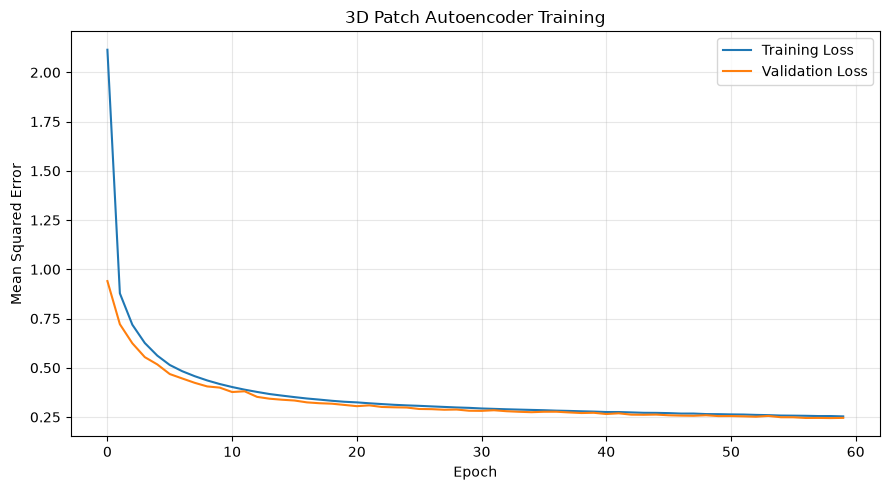

In [80]:
plt.figure(
    figsize=(9, 5)
)

plt.plot(
    training_losses,
    label="Training Loss"
)

plt.plot(
    validation_losses,
    label="Validation Loss"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Mean Squared Error"
)

plt.title(
    "3D Patch Autoencoder Training"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()

In [82]:
full_patch_loader = DataLoader(
    patch_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print(
    "Full dataset batches:",
    len(full_patch_loader)
)

Full dataset batches: 313


In [84]:
model.eval()

center_position = (
    PATCH_SIZE // 2
)

all_reconstruction_errors = []

with torch.no_grad():

    for patches in full_patch_loader:

        patches = patches.to(
            device
        )

        reconstructed_patches = model(
            patches
        )

        original_center_spectra = patches[
            :,
            :,
            :,
            center_position,
            center_position
        ]

        reconstructed_center_spectra = reconstructed_patches[
            :,
            :,
            :,
            center_position,
            center_position
        ]

        center_errors = torch.mean(
            (
                original_center_spectra
                - reconstructed_center_spectra
            ) ** 2,
            dim=(
                1,
                2
            )
        )

        all_reconstruction_errors.append(
            center_errors.cpu().numpy()
        )

reconstruction_errors = np.concatenate(
    all_reconstruction_errors
)

print(
    "Number of reconstruction errors:",
    len(reconstruction_errors)
)

print(
    "Minimum reconstruction error:",
    reconstruction_errors.min()
)

print(
    "Maximum reconstruction error:",
    reconstruction_errors.max()
)

print(
    "Mean reconstruction error:",
    reconstruction_errors.mean()
)

Number of reconstruction errors: 10000
Minimum reconstruction error: 0.0010889508
Maximum reconstruction error: 24.611319
Mean reconstruction error: 0.26664022


In [86]:
patch3d_anomaly_map = reconstruction_errors.reshape(
    height,
    width
)

print(
    "Anomaly map shape:",
    patch3d_anomaly_map.shape
)

Anomaly map shape: (100, 100)


In [88]:
normalized_anomaly_map = (
    patch3d_anomaly_map
    - patch3d_anomaly_map.min()
) / (
    patch3d_anomaly_map.max()
    - patch3d_anomaly_map.min()
    + 1e-8
)

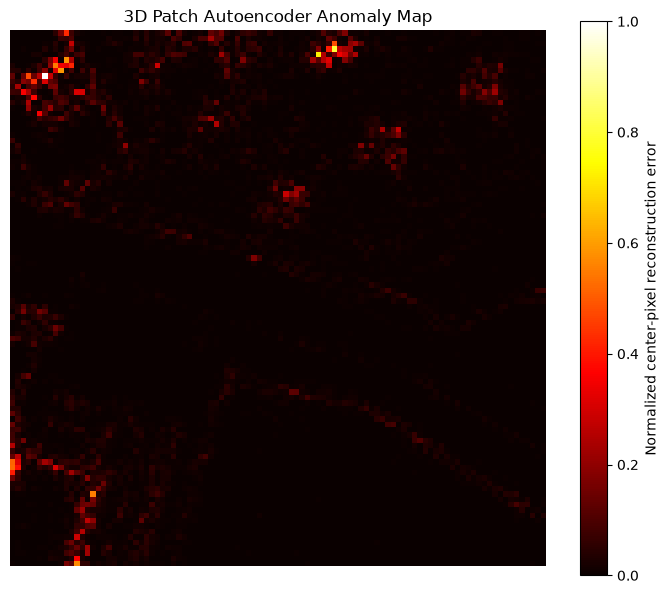

In [90]:
plt.figure(
    figsize=(7, 6)
)

plt.imshow(
    normalized_anomaly_map,
    cmap="hot"
)

plt.title(
    "3D Patch Autoencoder Anomaly Map"
)

plt.colorbar(
    label="Normalized center-pixel reconstruction error"
)

plt.axis(
    "off"
)

plt.tight_layout()

plt.show()

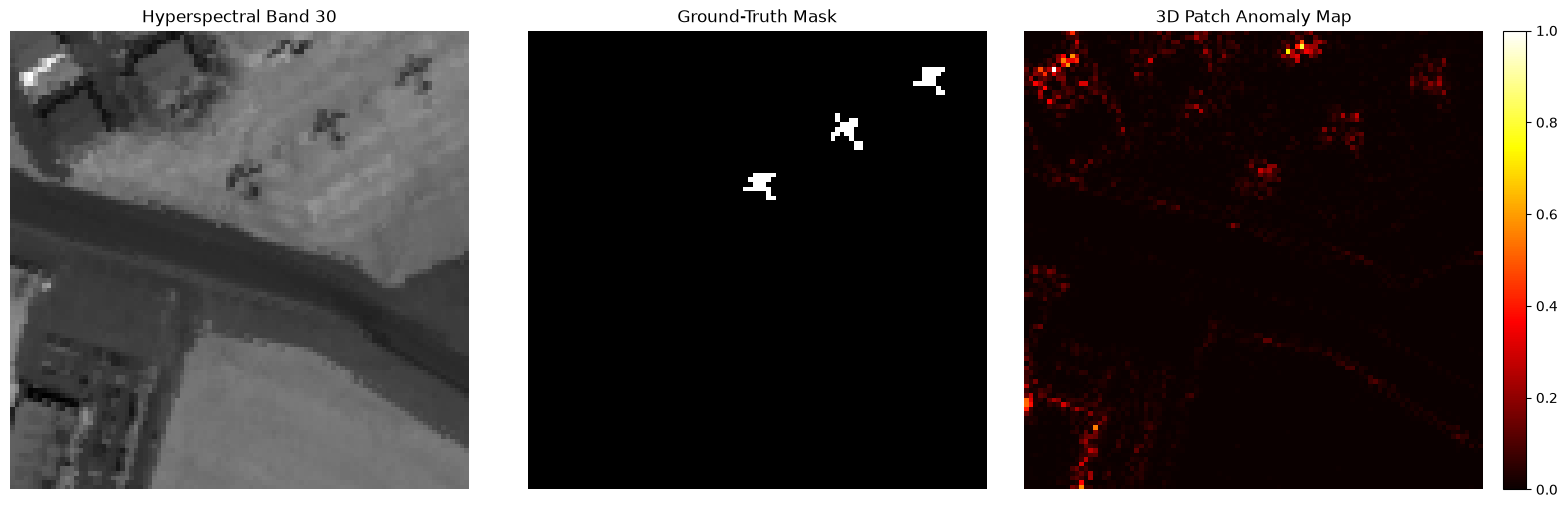

In [92]:
figure, axes = plt.subplots(
    1,
    3,
    figsize=(16, 5)
)

axes[0].imshow(
    cube[
        :,
        :,
        30
    ],
    cmap="gray"
)

axes[0].set_title(
    "Hyperspectral Band 30"
)

axes[0].axis(
    "off"
)

axes[1].imshow(
    ground_truth,
    cmap="gray"
)

axes[1].set_title(
    "Ground-Truth Mask"
)

axes[1].axis(
    "off"
)

image = axes[2].imshow(
    normalized_anomaly_map,
    cmap="hot"
)

axes[2].set_title(
    "3D Patch Anomaly Map"
)

axes[2].axis(
    "off"
)

figure.colorbar(
    image,
    ax=axes[2],
    fraction=0.046,
    pad=0.04
)

plt.tight_layout()

plt.show()

In [94]:
roc_auc = roc_auc_score(
    y,
    reconstruction_errors
)

pr_auc = average_precision_score(
    y,
    reconstruction_errors
)

print(
    f"ROC-AUC: "
    f"{roc_auc:.4f}"
)

print(
    f"PR-AUC: "
    f"{pr_auc:.4f}"
)

ROC-AUC: 0.9038
PR-AUC: 0.0423


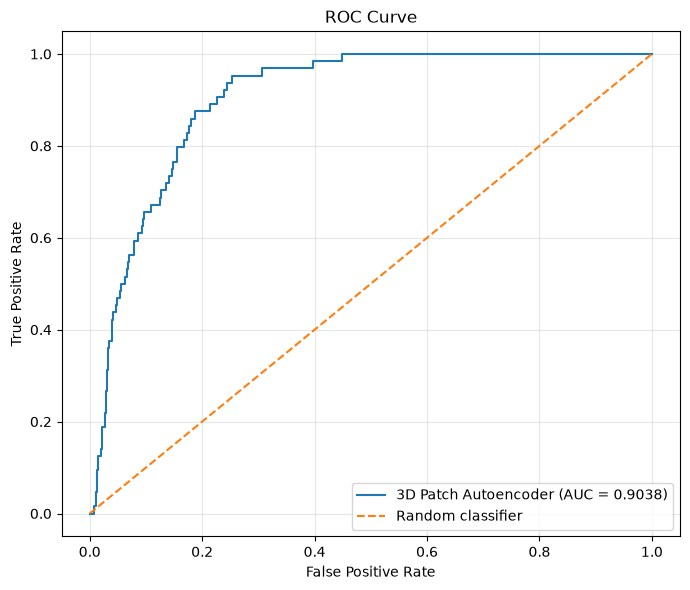

In [96]:
false_positive_rate, true_positive_rate, _ = roc_curve(
    y,
    reconstruction_errors
)

plt.figure(
    figsize=(7, 6)
)

plt.plot(
    false_positive_rate,
    true_positive_rate,
    label=(
        f"3D Patch Autoencoder "
        f"(AUC = {roc_auc:.4f})"
    )
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ROC Curve"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()

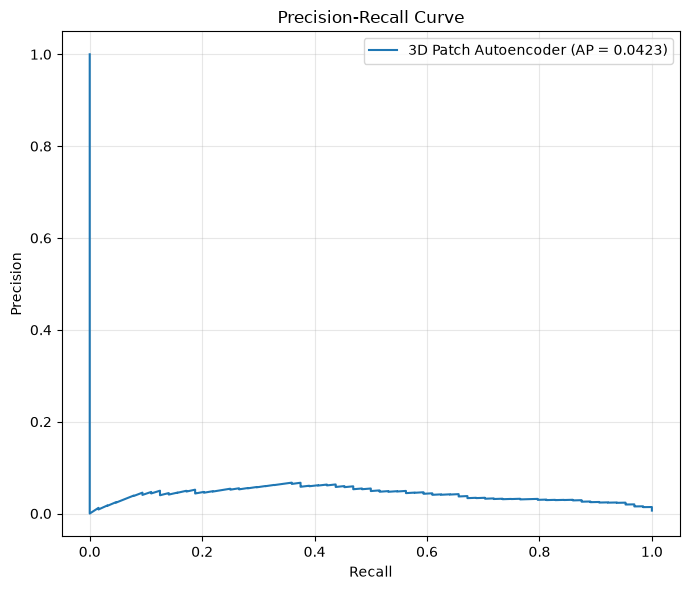

In [98]:
precision_values, recall_values, _ = precision_recall_curve(
    y,
    reconstruction_errors
)

plt.figure(
    figsize=(7, 6)
)

plt.plot(
    recall_values,
    precision_values,
    label=(
        f"3D Patch Autoencoder "
        f"(AP = {pr_auc:.4f})"
    )
)

plt.xlabel(
    "Recall"
)

plt.ylabel(
    "Precision"
)

plt.title(
    "Precision-Recall Curve"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()

In [100]:
THRESHOLD_PERCENTILE = 99

threshold = np.percentile(
    reconstruction_errors,
    THRESHOLD_PERCENTILE
)

predicted_labels = (
    reconstruction_errors
    >= threshold
).astype(
    np.uint8
)

predicted_mask = predicted_labels.reshape(
    height,
    width
)

print(
    "Threshold:",
    threshold
)

print(
    "Predicted anomaly pixels:",
    predicted_labels.sum()
)

Threshold: 3.9292288827896136
Predicted anomaly pixels: 100


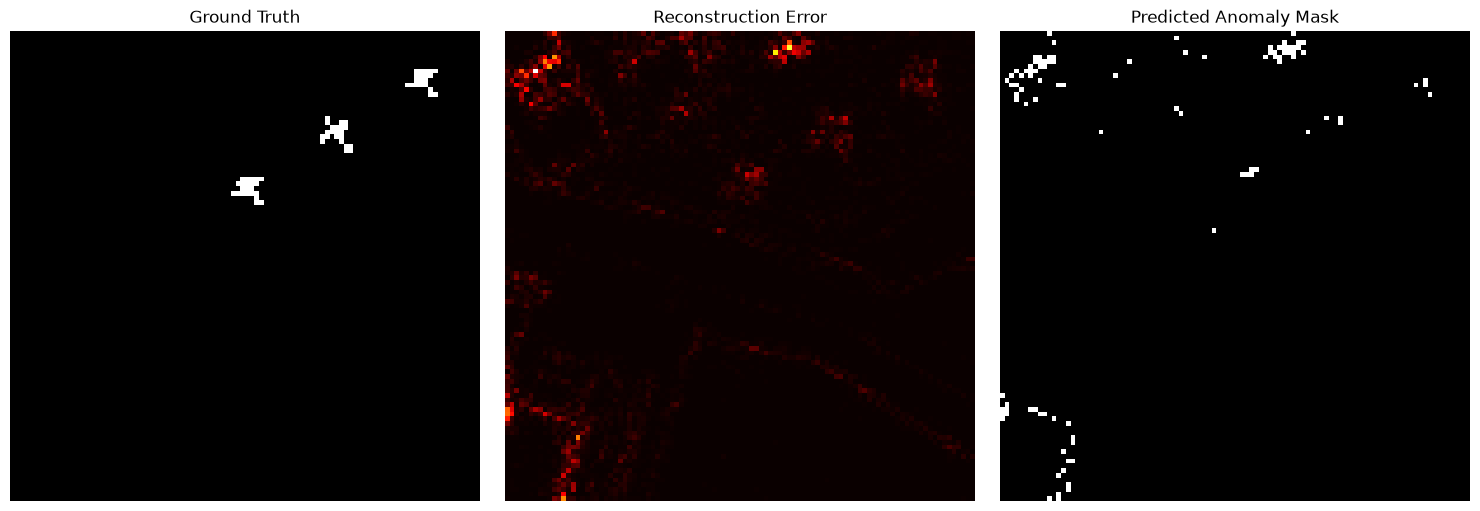

In [102]:
figure, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5)
)

axes[0].imshow(
    ground_truth,
    cmap="gray"
)

axes[0].set_title(
    "Ground Truth"
)

axes[0].axis(
    "off"
)

axes[1].imshow(
    normalized_anomaly_map,
    cmap="hot"
)

axes[1].set_title(
    "Reconstruction Error"
)

axes[1].axis(
    "off"
)

axes[2].imshow(
    predicted_mask,
    cmap="gray"
)

axes[2].set_title(
    "Predicted Anomaly Mask"
)

axes[2].axis(
    "off"
)

plt.tight_layout()

plt.show()

In [104]:
print(
    classification_report(
        y,
        predicted_labels,
        target_names=[
            "Background",
            "Anomaly"
        ],
        digits=4,
        zero_division=0
    )
)

              precision    recall  f1-score   support

  Background     0.9936    0.9900    0.9918      9936
     Anomaly     0.0100    0.0156    0.0122        64

    accuracy                         0.9838     10000
   macro avg     0.5018    0.5028    0.5020     10000
weighted avg     0.9873    0.9838    0.9856     10000



In [106]:
confusion_matrix_values = confusion_matrix(
    y,
    predicted_labels
)

confusion_matrix_table = pd.DataFrame(
    confusion_matrix_values,
    index=[
        "Actual Background",
        "Actual Anomaly"
    ],
    columns=[
        "Predicted Background",
        "Predicted Anomaly"
    ]
)

confusion_matrix_table

,Predicted Background,Predicted Anomaly
Actual Background,9837,99
Actual Anomaly,63,1


In [108]:
true_negative, false_positive, false_negative, true_positive = (
    confusion_matrix_values.ravel()
)

precision_score_value = (
    true_positive
    / (
        true_positive
        + false_positive
        + 1e-8
    )
)

recall_score_value = (
    true_positive
    / (
        true_positive
        + false_negative
        + 1e-8
    )
)

f1_score_value = (
    2
    * precision_score_value
    * recall_score_value
    / (
        precision_score_value
        + recall_score_value
        + 1e-8
    )
)

specificity = (
    true_negative
    / (
        true_negative
        + false_positive
        + 1e-8
    )
)

false_positive_rate_value = (
    false_positive
    / (
        false_positive
        + true_negative
        + 1e-8
    )
)

print(
    "True positives:",
    true_positive
)

print(
    "False positives:",
    false_positive
)

print(
    "False negatives:",
    false_negative
)

print(
    "True negatives:",
    true_negative
)

print(
    f"Precision: "
    f"{precision_score_value:.4f}"
)

print(
    f"Recall: "
    f"{recall_score_value:.4f}"
)

print(
    f"F1-score: "
    f"{f1_score_value:.4f}"
)

print(
    f"Specificity: "
    f"{specificity:.4f}"
)

print(
    f"False-positive rate: "
    f"{false_positive_rate_value:.6f}"
)

True positives: 1
False positives: 99
False negatives: 63
True negatives: 9837
Precision: 0.0100
Recall: 0.0156
F1-score: 0.0122
Specificity: 0.9900
False-positive rate: 0.009964


In [110]:
background_errors = reconstruction_errors[
    y == 0
]

anomaly_errors = reconstruction_errors[
    y == 1
]

print(
    "Mean background error:",
    background_errors.mean()
)

print(
    "Mean anomaly error:",
    anomaly_errors.mean()
)

print(
    "Median background error:",
    np.median(
        background_errors
    )
)

print(
    "Median anomaly error:",
    np.median(
        anomaly_errors
    )
)

Mean background error: 0.26041356
Mean anomaly error: 1.2333266
Median background error: 0.04273569
Median anomaly error: 0.92090845


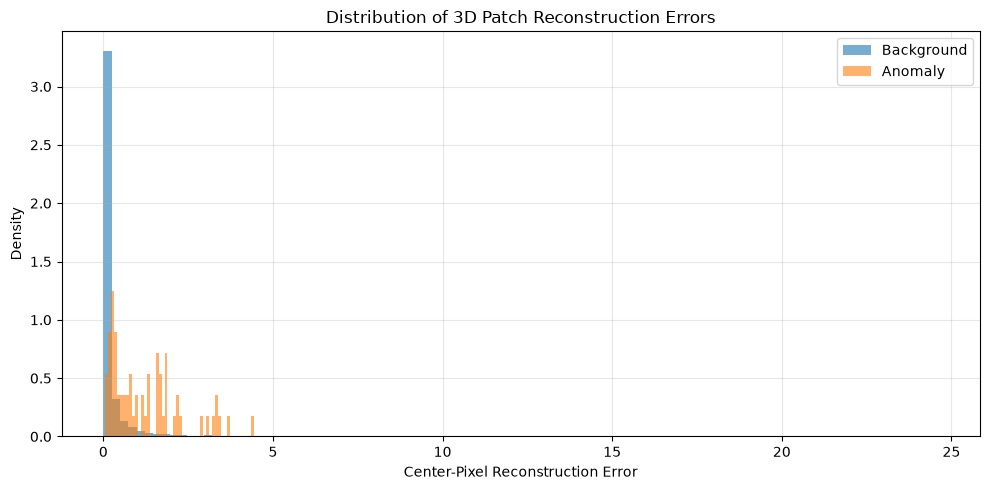

In [112]:
plt.figure(
    figsize=(10, 5)
)

plt.hist(
    background_errors,
    bins=100,
    alpha=0.6,
    density=True,
    label="Background"
)

plt.hist(
    anomaly_errors,
    bins=50,
    alpha=0.6,
    density=True,
    label="Anomaly"
)

plt.xlabel(
    "Center-Pixel Reconstruction Error"
)

plt.ylabel(
    "Density"
)

plt.title(
    "Distribution of 3D Patch Reconstruction Errors"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()

In [114]:
example_patch = patch_dataset[
    0
].numpy()

print(
    "Example patch shape:",
    example_patch.shape
)

Example patch shape: (1, 16, 9, 9)


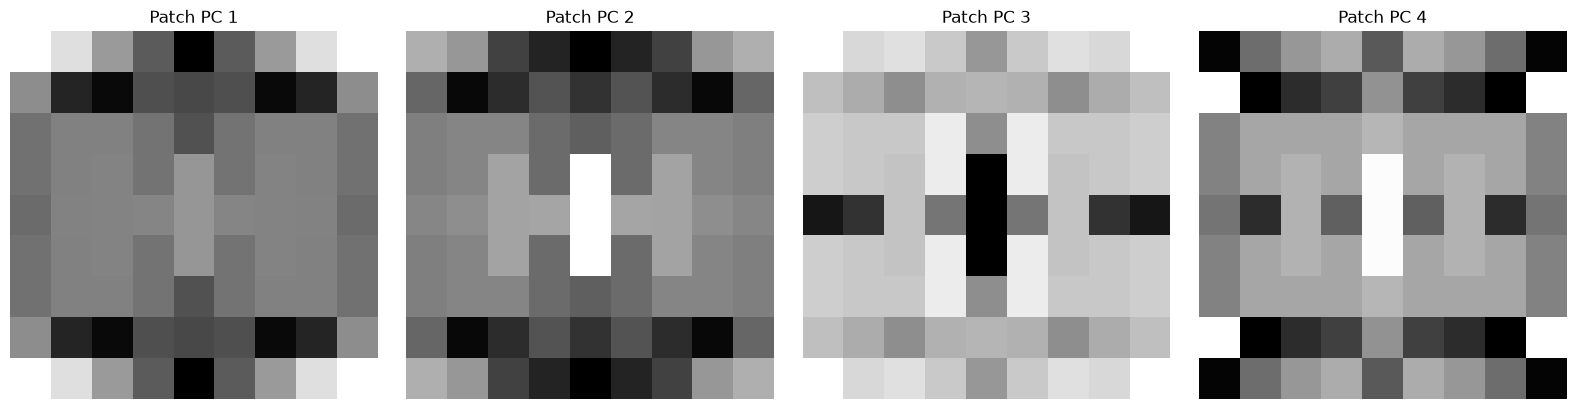

In [116]:
figure, axes = plt.subplots(
    1,
    4,
    figsize=(16, 4)
)

for component_index in range(4):

    axes[
        component_index
    ].imshow(
        example_patch[
            0,
            component_index,
            :,
            :
        ],
        cmap="gray"
    )

    axes[
        component_index
    ].set_title(
        f"Patch PC "
        f"{component_index + 1}"
    )

    axes[
        component_index
    ].axis(
        "off"
    )

plt.tight_layout()

plt.show()

In [118]:
model.eval()

all_latent_features = []

with torch.no_grad():

    for patches in full_patch_loader:

        patches = patches.to(
            device
        )

        latent_features = model.encoder(
            patches
        )

        pooled_features = torch.mean(
            latent_features,
            dim=(
                2,
                3,
                4
            )
        )

        all_latent_features.append(
            pooled_features.cpu().numpy()
        )

compact_embeddings = np.concatenate(
    all_latent_features,
    axis=0
)

print(
    "Compact embedding shape:",
    compact_embeddings.shape
)

Compact embedding shape: (10000, 32)


In [120]:
embedding_pca = PCA(
    n_components=2,
    random_state=RANDOM_STATE
)

two_dimensional_embeddings = embedding_pca.fit_transform(
    compact_embeddings
)

print(
    "Embedding PCA explained variance:",
    embedding_pca.explained_variance_ratio_
)

Embedding PCA explained variance: [0.5534582  0.37056252]


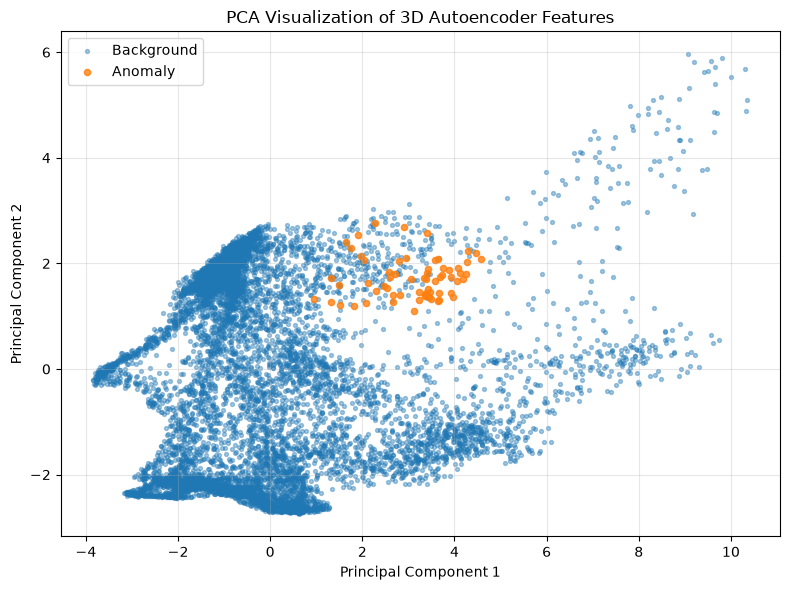

In [122]:
plt.figure(
    figsize=(8, 6)
)

plt.scatter(
    two_dimensional_embeddings[
        y == 0,
        0
    ],
    two_dimensional_embeddings[
        y == 0,
        1
    ],
    s=8,
    alpha=0.4,
    label="Background"
)

plt.scatter(
    two_dimensional_embeddings[
        y == 1,
        0
    ],
    two_dimensional_embeddings[
        y == 1,
        1
    ],
    s=20,
    alpha=0.8,
    label="Anomaly"
)

plt.xlabel(
    "Principal Component 1"
)

plt.ylabel(
    "Principal Component 2"
)

plt.title(
    "PCA Visualization of 3D Autoencoder Features"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()

In [124]:
MODEL_PATH = os.path.join(
    MODELS_DIR,
    "patch3d_autoencoder.pt"
)

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "number_of_pca_components": NUMBER_OF_PCA_COMPONENTS,
        "patch_size": PATCH_SIZE,
        "random_state": RANDOM_STATE,
        "training_losses": training_losses,
        "validation_losses": validation_losses
    },
    MODEL_PATH
)

print(
    "Model saved to:",
    MODEL_PATH
)

Model saved to: ../models/patch3d_autoencoder.pt


In [126]:
SCALER_PATH = os.path.join(
    MODELS_DIR,
    "patch3d_standard_scaler.joblib"
)

joblib.dump(
    scaler,
    SCALER_PATH
)

print(
    "Scaler saved to:",
    SCALER_PATH
)

Scaler saved to: ../models/patch3d_standard_scaler.joblib


In [128]:
PCA_PATH = os.path.join(
    MODELS_DIR,
    "patch3d_pca.joblib"
)

joblib.dump(
    pca,
    PCA_PATH
)

print(
    "PCA model saved to:",
    PCA_PATH
)

PCA model saved to: ../models/patch3d_pca.joblib


In [130]:
SCORE_PATH = os.path.join(
    RESULTS_DIR,
    "patch3d_autoencoder_scores.npy"
)

np.save(
    SCORE_PATH,
    patch3d_anomaly_map
)

print(
    "Anomaly scores saved to:",
    SCORE_PATH
)

Anomaly scores saved to: ../results/patch3d_autoencoder_scores.npy


In [132]:
EMBEDDING_PATH = os.path.join(
    RESULTS_DIR,
    "patch3d_compact_embeddings.npy"
)

np.save(
    EMBEDDING_PATH,
    compact_embeddings
)

print(
    "Compact embeddings saved to:",
    EMBEDDING_PATH
)

Compact embeddings saved to: ../results/patch3d_compact_embeddings.npy


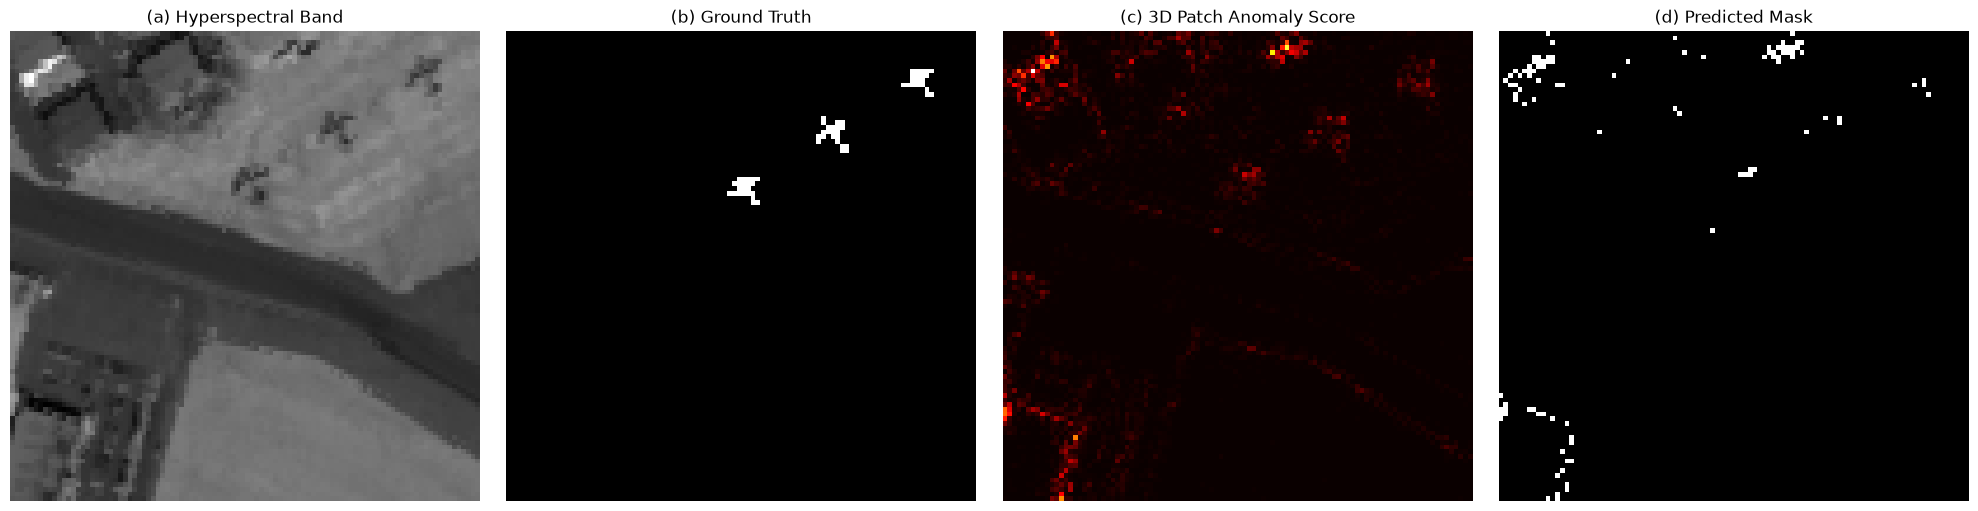

Figure saved to: ../results/patch3d_autoencoder_results.png


In [134]:
figure, axes = plt.subplots(
    1,
    4,
    figsize=(20, 5)
)

axes[0].imshow(
    cube[
        :,
        :,
        30
    ],
    cmap="gray"
)

axes[0].set_title(
    "(a) Hyperspectral Band"
)

axes[1].imshow(
    ground_truth,
    cmap="gray"
)

axes[1].set_title(
    "(b) Ground Truth"
)

axes[2].imshow(
    normalized_anomaly_map,
    cmap="hot"
)

axes[2].set_title(
    "(c) 3D Patch Anomaly Score"
)

axes[3].imshow(
    predicted_mask,
    cmap="gray"
)

axes[3].set_title(
    "(d) Predicted Mask"
)

for axis in axes:

    axis.axis(
        "off"
    )

plt.tight_layout()

FIGURE_PATH = os.path.join(
    RESULTS_DIR,
    "patch3d_autoencoder_results.png"
)

plt.savefig(
    FIGURE_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Figure saved to:",
    FIGURE_PATH
)

In [136]:
results_table = pd.DataFrame(
    {
        "Dataset": [
            "AVIRIS-1 San Diego"
        ],

        "Model": [
            "3D Patch Autoencoder"
        ],

        "PCA_Components": [
            NUMBER_OF_PCA_COMPONENTS
        ],

        "Patch_Size": [
            PATCH_SIZE
        ],

        "ROC_AUC": [
            roc_auc
        ],

        "PR_AUC": [
            pr_auc
        ],

        "Threshold_Percentile": [
            THRESHOLD_PERCENTILE
        ],

        "Precision": [
            precision_score_value
        ],

        "Recall": [
            recall_score_value
        ],

        "F1": [
            f1_score_value
        ],

        "Specificity": [
            specificity
        ],

        "False_Positive_Rate": [
            false_positive_rate_value
        ],

        "Training_Time_Seconds": [
            training_time
        ],

        "Trainable_Parameters": [
            number_of_parameters
        ]
    }
)

results_table

,Dataset,Model,PCA_Components,Patch_Size,ROC_AUC,PR_AUC,Threshold_Percentile,Precision,Recall,F1,Specificity,False_Positive_Rate,Training_Time_Seconds,Trainable_Parameters
0,AVIRIS-1 San Diego,3D Patch Autoencoder,16,9,0.903756,0.04229,99,0.01,0.015625,0.012195,0.990036,0.009964,283.297119,35073


In [138]:
METRICS_PATH = os.path.join(
    RESULTS_DIR,
    "patch3d_autoencoder_metrics.csv"
)

results_table.to_csv(
    METRICS_PATH,
    index=False
)

print(
    "Metrics saved to:",
    METRICS_PATH
)

Metrics saved to: ../results/patch3d_autoencoder_metrics.csv


In [140]:
DENSE_METRICS_PATH = os.path.join(
    RESULTS_DIR,
    "spectral_dense_autoencoder_metrics.csv"
)

CONV1D_METRICS_PATH = os.path.join(
    RESULTS_DIR,
    "conv1d_autoencoder_metrics.csv"
)

comparison_tables = []

if os.path.exists(
    DENSE_METRICS_PATH
):

    comparison_tables.append(
        pd.read_csv(
            DENSE_METRICS_PATH
        )
    )

if os.path.exists(
    CONV1D_METRICS_PATH
):

    comparison_tables.append(
        pd.read_csv(
            CONV1D_METRICS_PATH
        )
    )

comparison_tables.append(
    results_table
)

autoencoder_comparison = pd.concat(
    comparison_tables,
    ignore_index=True
)

display_columns = [
    "Model",
    "ROC_AUC",
    "PR_AUC",
    "Precision",
    "Recall",
    "F1",
    "Training_Time_Seconds",
    "Trainable_Parameters"
]

available_display_columns = [
    column
    for column in display_columns
    if column in autoencoder_comparison.columns
]

display(
    autoencoder_comparison[
        available_display_columns
    ].round(4)
)

,Model,ROC_AUC,PR_AUC,Precision,Recall,F1,Training_Time_Seconds,Trainable_Parameters
0,Spectral Dense Autoencoder,0.9106,0.0346,0.00,0.0000,0.0000,5.3244,69725
1,1D CNN Autoencoder,0.8944,0.0350,0.00,0.0000,0.0000,160.9251,17793
2,3D Patch Autoencoder,0.9038,0.0423,0.01,0.0156,0.0122,283.2971,35073


In [142]:
COMPARISON_PATH = os.path.join(
    RESULTS_DIR,
    "three_autoencoder_comparison.csv"
)

autoencoder_comparison.to_csv(
    COMPARISON_PATH,
    index=False
)

print(
    "Combined comparison saved to:",
    COMPARISON_PATH
)

Combined comparison saved to: ../results/three_autoencoder_comparison.csv


In [144]:
print(
    "=" * 75
)

print(
    "3D SPECTRAL-SPATIAL AUTOENCODER "
    "EXPERIMENT SUMMARY"
)

print(
    "=" * 75
)

print(
    "Dataset: AVIRIS-1 San Diego"
)

print(
    "Original cube shape:",
    cube.shape
)

print(
    "PCA cube shape:",
    pca_cube.shape
)

print(
    "Patch size:",
    PATCH_SIZE
)

print(
    "PCA components:",
    NUMBER_OF_PCA_COMPONENTS
)

print(
    "Model: 3D Patch Autoencoder"
)

print(
    "Trainable parameters:",
    number_of_parameters
)

print(
    f"Training time: "
    f"{training_time:.2f} seconds"
)

print(
    f"ROC-AUC: "
    f"{roc_auc:.4f}"
)

print(
    f"PR-AUC: "
    f"{pr_auc:.4f}"
)

print(
    f"Precision: "
    f"{precision_score_value:.4f}"
)

print(
    f"Recall: "
    f"{recall_score_value:.4f}"
)

print(
    f"F1-score: "
    f"{f1_score_value:.4f}"
)

print(
    f"Specificity: "
    f"{specificity:.4f}"
)

print(
    "Saved model:",
    MODEL_PATH
)

print(
    "Saved anomaly map:",
    SCORE_PATH
)

print(
    "Saved embeddings:",
    EMBEDDING_PATH
)

print(
    "=" * 75
)

3D SPECTRAL-SPATIAL AUTOENCODER EXPERIMENT SUMMARY
Dataset: AVIRIS-1 San Diego
Original cube shape: (100, 100, 189)
PCA cube shape: (100, 100, 16)
Patch size: 9
PCA components: 16
Model: 3D Patch Autoencoder
Trainable parameters: 35073
Training time: 283.30 seconds
ROC-AUC: 0.9038
PR-AUC: 0.0423
Precision: 0.0100
Recall: 0.0156
F1-score: 0.0122
Specificity: 0.9900
Saved model: ../models/patch3d_autoencoder.pt
Saved anomaly map: ../results/patch3d_autoencoder_scores.npy
Saved embeddings: ../results/patch3d_compact_embeddings.npy
